In [1]:
import os
os.chdir('..')
print("current working directory:", os.getcwd())

current working directory: e:\Portfolio Project\GREEN HARVEST SEEDS INDIA PVT. LTD\Project


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/india_agriculture_seed_sales_data.csv')


In [5]:
df.head(5)

,Date,Year,Month,Region,Vegetable_Type,Warehouse_Quantity,Competitor_Market_Share_%,Company_Market_Share_%,Farmer_Sentiment_Score,Soil_pH,...,Wholesale_Price,Retail_Price,Farmer_Share_%,Sales_Target,Actual_Units_Sold,Total_Revenue,Total_Cost,Profit_Margin_%,Revenue_Growth_%,Days_to_Sell_Inventory
0,2021-01,2021,1,West,Carrot,5983,68.0,32.0,9.48,7.03,...,307.88,554.18,28.4,951,1123,230495.44,207676.39,9.90,3.55,61.3
1,2021-01,2021,1,Central,Chili,6704,42.3,57.7,4.86,6.12,...,253.20,455.76,20.7,868,1061,179093.74,159160.61,11.13,6.84,68.2
2,2021-01,2021,1,East,Chili,6383,59.7,40.3,8.62,6.19,...,239.67,431.41,26.1,1045,575,91872.03,79258.00,13.73,2.56,44.2
3,2021-01,2021,1,Central,Chili,4844,50.7,49.3,7.23,7.44,...,314.94,566.89,24.8,802,625,131222.69,114137.50,13.02,1.28,79.7
4,2021-01,2021,1,Central,Tomato,6924,49.3,50.7,7.73,7.40,...,336.13,605.03,21.1,1478,1030,230816.33,204341.70,11.47,4.80,75.5


In [3]:
## Null Check
print("Nulls:", df.isnull().sum().sum())

Nulls: 0


In [6]:
## Unique values

print("Regions:", df['Region'].unique())           # 5 regions
print("Vegetables:", df['Vegetable_Type'].unique()) # 20 crops
print("Year Range:", df['Year'].min(), '–', df['Year'].max())

Regions: <StringArray>
['West', 'Central', 'East', 'South', 'North']
Length: 5, dtype: str
Vegetables: <StringArray>
['Carrot', 'Chili', 'Tomato', 'Onion', 'Cauliflower', 'Okra']
Length: 6, dtype: str
Year Range: 2021 – 2026


 Revenue Trend by Year

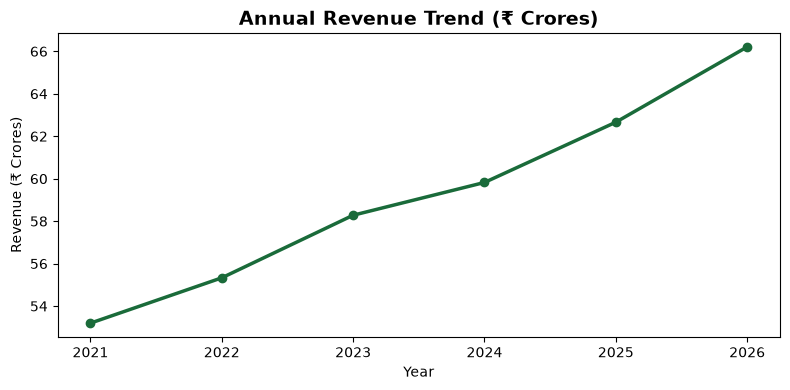

In [8]:
rev_year = df.groupby('Year')['Total_Revenue'].sum() / 1e7  # in Crores
plt.figure(figsize=(8,4))
plt.plot(rev_year.index, rev_year.values, marker='o', color='#1a6b3a', linewidth=2.5)
plt.title('Annual Revenue Trend (₹ Crores)', fontsize=14, fontweight='bold')
plt.xlabel('Year'); plt.ylabel('Revenue (₹ Crores)')
plt.tight_layout(); plt.savefig('../outputs/figures/revenue_trend.png', dpi = 150)


Profit Margin by Region

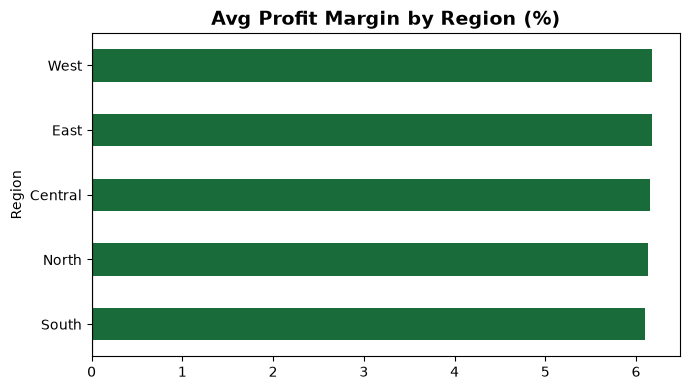

In [9]:
region_profit = df.groupby('Region')['Profit_Margin_%'].mean().sort_values()
plt.figure(figsize=(7,4))
colors = ['#d32f2f' if v < 0 else '#1a6b3a' for v in region_profit.values]
region_profit.plot(kind='barh', color=colors)
plt.title('Avg Profit Margin by Region (%)', fontsize=14, fontweight='bold')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout(); plt.savefig('../outputs/figures/region_profit.png', dpi = 150)

Profit by Vegetable Type 

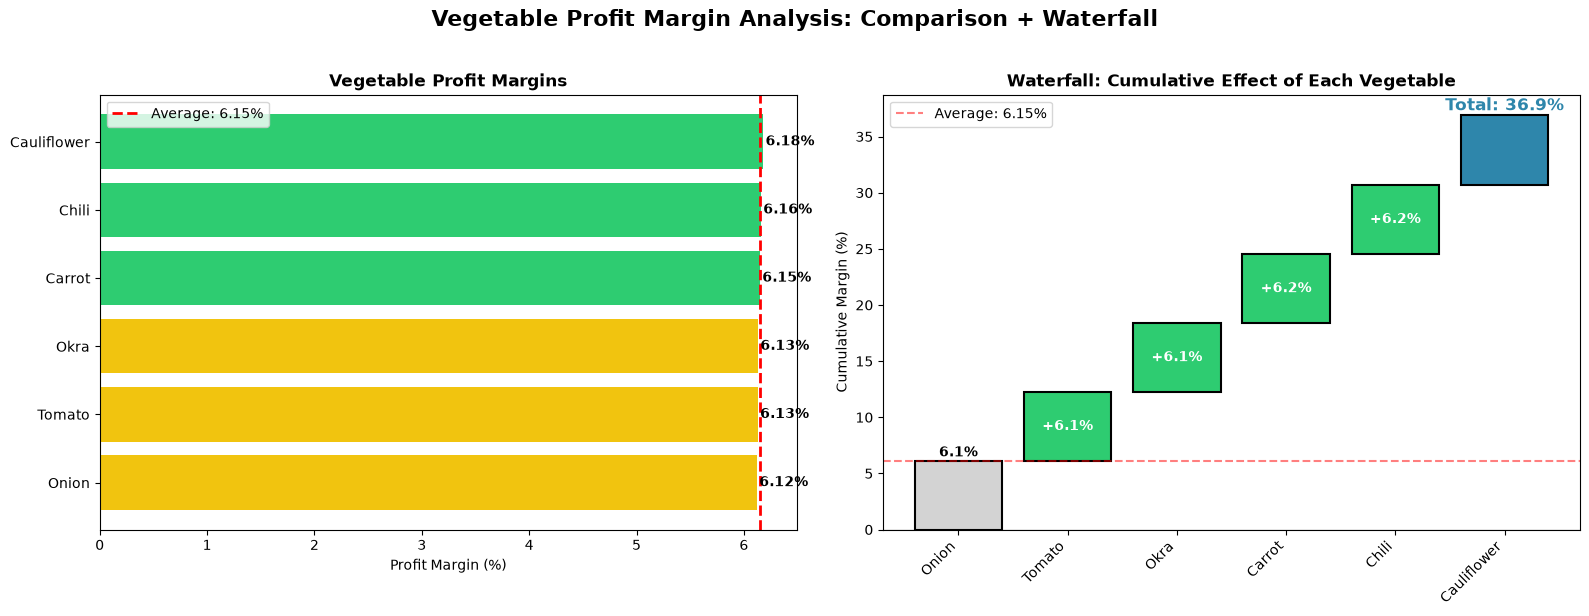

In [12]:


veg_profit = df.groupby('Vegetable_Type')['Profit_Margin_%'].mean().sort_values()

# Create DataFrame with explicit float dtype
data = pd.DataFrame({
    'Vegetable': veg_profit.index,
    'Margin': veg_profit.values.astype(float)  # Force float
})

# Sort by margin (ascending for waterfall effect)
data = data.sort_values('Margin', ascending=True).reset_index(drop=True)

# Calculate cumulative metrics
data['Cumulative_Avg'] = data['Margin'].expanding().mean().astype(float)
overall_avg = float(data['Margin'].mean())
data['Deviation'] = (data['Margin'] - overall_avg).astype(float)
data['Cumulative_Deviation'] = data['Deviation'].cumsum().astype(float)

# Create columns with float dtype
data['Base'] = 0.0
data['End'] = 0.0

# Calculate waterfall bases
for i in range(len(data)):
    if i == 0:
        data.loc[i, 'Base'] = 0.0
        data.loc[i, 'End'] = float(data.loc[i, 'Margin'])
    else:
        data.loc[i, 'Base'] = float(data.loc[i-1, 'End'])
        data.loc[i, 'End'] = float(data.loc[i-1, 'End']) + float(data.loc[i, 'Margin'])

# Create the visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Margin Comparison
bars = ax1.barh(data['Vegetable'], data['Margin'], 
                color=['#2ECC71' if x > overall_avg else '#F1C40F' for x in data['Margin']])
ax1.axvline(x=overall_avg, color='red', linestyle='--', linewidth=2, 
           label=f'Average: {overall_avg:.2f}%')
ax1.set_xlabel('Profit Margin (%)')
ax1.set_title('Vegetable Profit Margins', fontweight='bold')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, data['Margin'])):
    ax1.text(float(val) + 0.02, bar.get_y() + bar.get_height()/2, 
             f'{val:.2f}%', va='center', fontweight='bold')
ax1.legend()

# Chart 2: Waterfall (Cumulative Effect)
# Colors for waterfall
bar_colors = ['#D3D3D3'] + ['#2ECC71'] * (len(data) - 2) + ['#2E86AB']

# Create waterfall bars
bars = ax2.bar(range(len(data)), data['Margin'].astype(float), 
               bottom=data['Base'].astype(float), 
               color=bar_colors, edgecolor='black', linewidth=1.5)

# Connecting lines
for i in range(1, len(data)):
    ax2.plot([i-0.4, i-0.4], 
             [float(data.loc[i-1, 'End']), float(data.loc[i, 'Base'])], 
             color='black', linestyle='-', linewidth=1.5)

# Labels
for i, row in data.iterrows():
    if i == 0:
        # Starting bar
        ax2.text(i, float(row['Margin']) + 0.1, f'{row["Margin"]:.1f}%', 
                ha='center', va='bottom', fontweight='bold')
    elif i == len(data) - 1:
        # Total bar
        total = float(row['End'])
        ax2.text(i, total + 0.1, f'Total: {total:.1f}%', 
                ha='center', va='bottom', fontweight='bold', 
                color='#2E86AB', fontsize=12)
    else:
        # Intermediate bars
        mid = float(row['Base']) + float(row['Margin'])/2
        ax2.text(i, mid, f'+{row["Margin"]:.1f}%', ha='center', va='center', 
                color='white', fontweight='bold', fontsize=10)

ax2.set_xticks(range(len(data)))
ax2.set_xticklabels(data['Vegetable'], rotation=45, ha='right')
ax2.set_ylabel('Cumulative Margin (%)')
ax2.set_title('Waterfall: Cumulative Effect of Each Vegetable', fontweight='bold')
ax2.axhline(y=overall_avg, color='red', linestyle='--', alpha=0.5, 
           label=f'Average: {overall_avg:.2f}%')
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.legend()

plt.suptitle('Vegetable Profit Margin Analysis: Comparison + Waterfall', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/vegetable_profit_combined_analysis.png', 
            dpi=150, bbox_inches='tight')
plt.show()

Correlation Heatmap

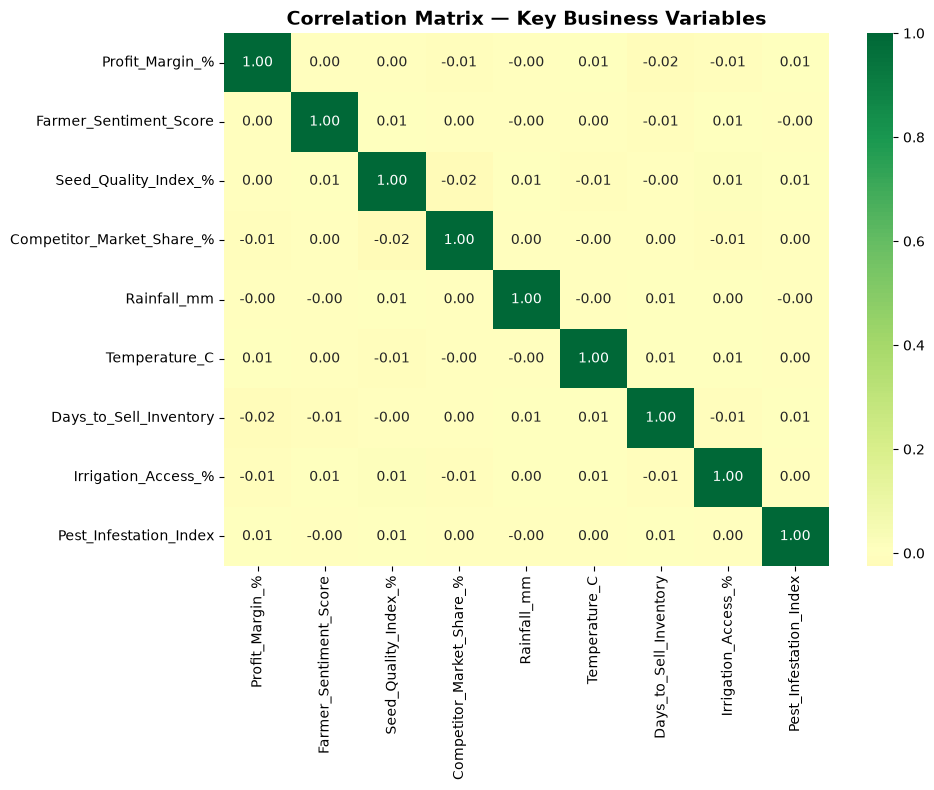

In [13]:
numeric_cols = ['Profit_Margin_%','Farmer_Sentiment_Score','Seed_Quality_Index_%',
                'Competitor_Market_Share_%','Rainfall_mm','Temperature_C',
                'Days_to_Sell_Inventory','Irrigation_Access_%','Pest_Infestation_Index']
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Correlation Matrix — Key Business Variables', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('../outputs/figures/correlation_heatmap.png', dpi = 150)

In [14]:
# Step 1: Check for data quality issues
print("=== DATA QUALITY CHECK ===")

# Check missing values
missing = df.isnull().sum()
print(f"Missing values:\n{missing[missing > 0]}")

# Check for outliers
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = df[(df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)]
    if len(outliers) > 0:
        print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")

# Check for constant values
for col in numeric_cols:
    if df[col].std() < 0.01:
        print(f"⚠️ {col} has almost no variation!")

# Check for data entry errors
print("\n=== SAMPLE DATA ===")
print(df[numeric_cols].head(10))

# Check for unrealistic values
print("\n=== VALUE RANGES ===")
for col in numeric_cols:
    print(f"{col}: {df[col].min():.2f} - {df[col].max():.2f}")

=== DATA QUALITY CHECK ===
Missing values:
Series([], dtype: int64)

=== SAMPLE DATA ===
   Profit_Margin_%  Farmer_Sentiment_Score  Seed_Quality_Index_%  \
0             9.90                    9.48                  97.5   
1            11.13                    4.86                  88.8   
2            13.73                    8.62                  85.0   
3            13.02                    7.23                  97.7   
4            11.47                    7.73                  88.6   
5            14.14                    7.32                  97.5   
6             8.38                    8.78                  91.0   
7            12.21                    7.50                  86.1   
8             9.94                    8.67                  92.7   
9            11.12                    4.85                  97.7   

   Competitor_Market_Share_%  Rainfall_mm  Temperature_C  \
0                       68.0          0.3           32.0   
1                       42.3          1.8 

In [15]:
# How much variation do you actually have?
for col in numeric_cols:
    variation = df[col].max() - df[col].min()
    relative_variation = (df[col].std() / df[col].mean()) * 100
    print(f"{col}: Range={variation:.2f}, CV={relative_variation:.1f}%")

# If variation is low, correlations will naturally be low

Profit_Margin_%: Range=14.00, CV=59.5%
Farmer_Sentiment_Score: Range=5.50, CV=23.4%
Seed_Quality_Index_%: Range=13.00, CV=4.1%
Competitor_Market_Share_%: Range=35.00, CV=17.5%
Rainfall_mm: Range=150.00, CV=57.3%
Temperature_C: Range=17.00, CV=18.6%
Days_to_Sell_Inventory: Range=50.00, CV=22.2%
Irrigation_Access_%: Range=45.00, CV=18.0%
Pest_Infestation_Index: Range=0.14, CV=50.5%


In [16]:
# Segment by Region
regions = df['Region'].unique()
results = []

for region in regions:
    subset = df[df['Region'] == region]
    
    # Calculate correlations within this region
    region_corr = subset[numeric_cols].corr()['Profit_Margin_%']
    
    for factor in numeric_cols:
        if factor != 'Profit_Margin_%':
            results.append({
                'Region': region,
                'Factor': factor,
                'Correlation': region_corr[factor],
                'Sample_Size': len(subset)
            })

# Convert to DataFrame
segment_results = pd.DataFrame(results)

# Find strong correlations within segments
strong_correlations = segment_results[
    abs(segment_results['Correlation']) > 0.3
].sort_values('Correlation', key=abs, ascending=False)

print("=== STRONG SEGMENT CORRELATIONS ===")
print(strong_correlations)

# Example output you might find:
# Region: Maharashtra, Factor: Rainfall_mm, Correlation: 0.65 (Strong!)
# Region: Gujarat, Factor: Seed_Quality, Correlation: 0.58 (Strong!)

=== STRONG SEGMENT CORRELATIONS ===
Empty DataFrame
Columns: [Region, Factor, Correlation, Sample_Size]
Index: []
